![title](imagens/cabec_08g.jpg)

# <font color='green'>Projeto 6 - Marketing para Instituições Financeiras - Parte 08</font>
## <font color='green'>Algumas análises e finalização</font>

## Carregando os Pacotes e o Dataset

In [1]:
# Importação dos Pacotes necessários para este projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Carrega o dataset
df = pd.read_csv("dados/bank-full_final.csv") 

In [3]:
# Shape
df.shape

(45204, 18)

In [4]:
# Amostra
df.head()

,Unnamed: 0,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,previous,poutcome,target,marital,education
0,0,58,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,0,unknown,no,married,tertiary
1,1,44,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,0,unknown,no,single,secondary
2,2,33,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,0,unknown,no,married,secondary
3,3,47,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,0,unknown,no,married,unknown
4,4,33,unknown,60000.0,1,no,no,no,unknown,5,may,198,1,0,unknown,no,single,unknown


In [5]:
# Como removemos o id, ao sarvar o arquivo, o pandas cria uma nova coluna de identificação e ele chama de Unnamed:0 
# Vamos removê-la.
df.drop(["Unnamed: 0"], axis = 1, inplace = True)

In [6]:
# Amostra
df.head()

,age,job,salary,balance,default,housing,loan,contact,day,month,duration,campaign,previous,poutcome,target,marital,education
0,58,management,100000.0,2143,no,yes,no,unknown,5,may,261,1,0,unknown,no,married,tertiary
1,44,technician,60000.0,29,no,yes,no,unknown,5,may,151,1,0,unknown,no,single,secondary
2,33,entrepreneur,120000.0,2,no,yes,yes,unknown,5,may,76,1,0,unknown,no,married,secondary
3,47,blue-collar,20000.0,1506,no,yes,no,unknown,5,may,92,1,0,unknown,no,married,unknown
4,33,unknown,60000.0,1,no,no,no,unknown,5,may,198,1,0,unknown,no,single,unknown


In [7]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45204 entries, 0 to 45203
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45204 non-null  int64  
 1   job        45204 non-null  object 
 2   salary     45204 non-null  float64
 3   balance    45204 non-null  int64  
 4   default    45204 non-null  object 
 5   housing    45204 non-null  object 
 6   loan       45204 non-null  object 
 7   contact    45204 non-null  object 
 8   day        45204 non-null  int64  
 9   month      45204 non-null  object 
 10  duration   45204 non-null  int64  
 11  campaign   45204 non-null  int64  
 12  previous   45204 non-null  int64  
 13  poutcome   45204 non-null  object 
 14  target     45204 non-null  object 
 15  marital    45204 non-null  object 
 16  education  45204 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 5.9+ MB


In [8]:
# Temos valores nulos?
df.isna().any()

age          False
job          False
salary       False
balance      False
default      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
previous     False
poutcome     False
target       False
marital      False
education    False
dtype: bool

In [9]:
# Temos valores nulos?
df.isna().sum()

age          0
job          0
salary       0
balance      0
default      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
previous     0
poutcome     0
target       0
marital      0
education    0
dtype: int64

## Análise dos Dados
Alguma análises que podem ser feitas e entregues para a área de negócio ou para a equipe que fará o "data science", tentando reconhecer algum padrão ou mesmo estabelecer um modelo de possível previsão, no caso, de opção ou não pela campanha de marketing.

### Análise Univariada
A **análise univariada** compreende *explicar a distribuição de uma única variável*, incluindo sua medida central (média, mediana e a moda) e sua dispersão (incluindo a diferença entre o maior e menor valor da amostragem e quantis do conjunto de dados, além da variância e desvio padrão).

Vamos analisar três colunas (variáveis): estado civil (marital), profissão (job) e nível educacional (education)

In [10]:
# Análise da coluna/variável estado civil (marital)
df.marital.value_counts(normalize = True)

marital
married     0.601938
single      0.282917
divorced    0.115145
Name: proportion, dtype: float64

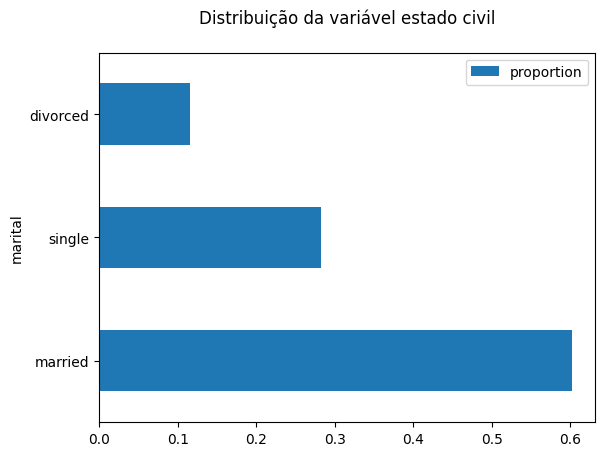

In [11]:
# Agora no formato gráfico (gráfico de barras)
df.marital.value_counts(normalize = True).plot(kind = "barh")
plt.title("Distribuição da variável estado civil\n")
plt.legend()
plt.show()

In [12]:
# Análise da coluna/variável profissão (job)
df.job.value_counts(normalize = True)

job
blue-collar      0.215269
management       0.209207
technician       0.168038
admin.           0.114370
services         0.091895
retired          0.050018
self-employed    0.034931
entrepreneur     0.032895
unemployed       0.028825
housemaid        0.027431
student          0.020750
unknown          0.006371
Name: proportion, dtype: float64

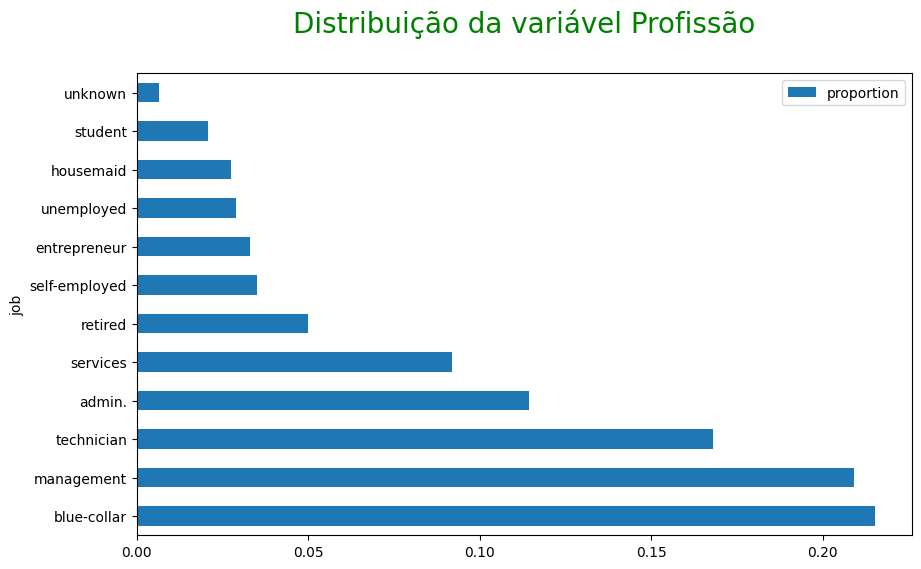

In [13]:
# Agora no formato gráfico (gráfico de barras)
plt.figure(figsize = (10,6))
df.job.value_counts(normalize = True).plot(kind = "barh")
plt.title("Distribuição da variável Profissão\n", fontdict = {'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})
plt.legend()
plt.show()

In [14]:
# Análise da coluna/variável nível educacional (education)
df.education.value_counts(normalize = True)

education
secondary    0.513251
tertiary     0.294178
primary      0.151491
unknown      0.041080
Name: proportion, dtype: float64

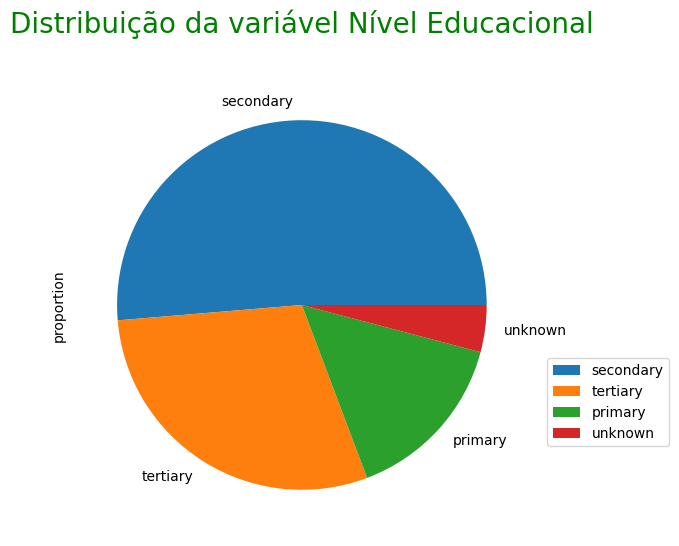

In [15]:
# Agora no formato gráfico (gráfico de pizza)
plt.figure(figsize = (10,6))
df.education.value_counts(normalize = True).plot(kind = "pie")
plt.title("Distribuição da variável Nível Educacional\n", fontdict = {'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})
plt.legend()
plt.legend(bbox_to_anchor=(1.31,0.4))
plt.show()

### Análise Multivariada
A **Análise Multivariada** refere-se a um conjunto de métodos estatísticos que permitem analisar simultaneamente várias variáveis medidas em cada elemento amostral. Esses métodos têm como objetivo simplificar ou facilitar a interpretação do fenômeno que está sendo estudado, identificando os fatores e as relações entre eles. Alguns exemplos de métodos de análise multivariada são: análise de correspondência ou matriz de correspondência, análise de componentes principais, análise fatorial, análise de cluster, análise de regressão múltipla e modelagem de equações estruturais.
Por exemplo... será que existe alguma correlação entre idade, saldo em conta corrente e salário?

In [16]:
# Calcula a correlação
res = df[["salary", "balance", "age"]].corr()

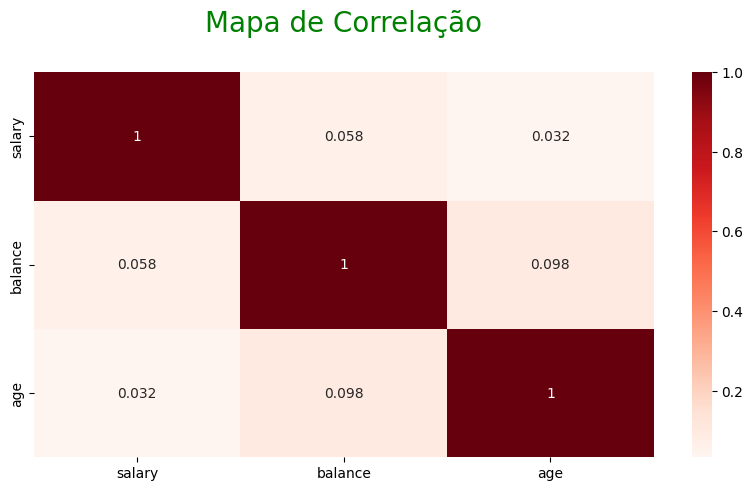

In [17]:
# Mapa de Correlação
plt.figure(figsize = (10,5))
sns.heatmap(res, annot = True, cmap = "Reds")
plt.title("Mapa de Correlação\n", fontdict = {'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})
plt.show()

Uma outra análise multivariada que pode ser feita é identificar se existe alguma correlação entre o salário e a opção por aderir a campanha de marketing. Será que as pessoas que ganham mais foram mais propensas a dizer "sim"?

In [18]:
# Agrupa o salário pela variável alvo (target) e calcula a média
df.groupby(by = ["target"])["salary"].mean()

target
no     57160.537128
yes    59156.770045
Name: salary, dtype: float64

In [19]:
# Agrupa o salário pela variável resposta e calcula a mediana
df.groupby(by = ["target"])["salary"].median()

target
no     60000.0
yes    60000.0
Name: salary, dtype: float64

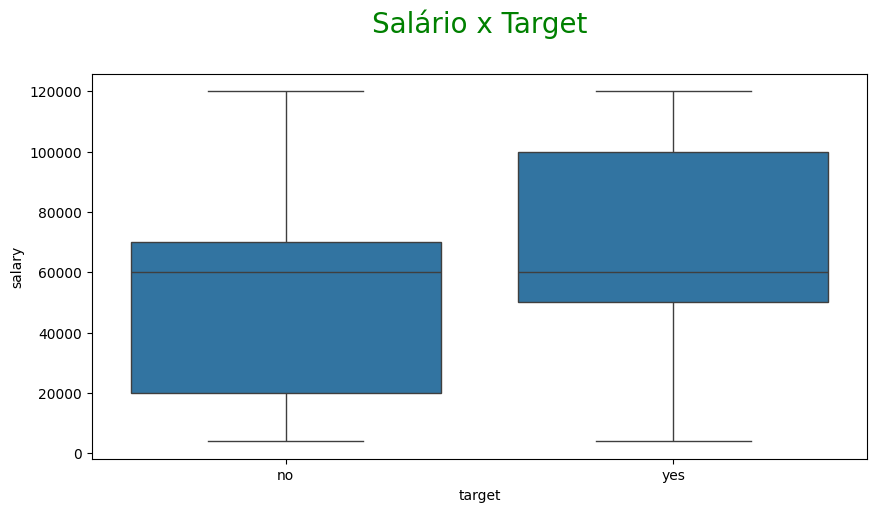

In [20]:
# Boxplot
plt.figure(figsize = (10,5))
sns.boxplot(x=df["target"], y=df["salary"])
plt.title("Salário x Target\n", fontdict = {'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})
plt.show()

# Fim